In [77]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
# Configuração dos caminhos do projeto

PROJECT_ROOT = Path.cwd().parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"

PROCESSED_FILE = PROCESSED_DIR / "wine_quality_clean.csv"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

In [79]:
# Carregamento da base limpa

wine_df = pd.read_csv(PROCESSED_FILE)

print(f"Dimensões da base limpa: {wine_df.shape[0]} linhas e {wine_df.shape[1]} colunas")

wine_df.head()

Dimensões da base limpa: 1018 linhas e 13 colunas


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_binary
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,0


In [80]:
# Estatísticas descritivas das variáveis numéricas

wine_df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1018.0,8.288507,1.741324,4.60000,7.100000,7.900000,9.100000,15.90000
volatile acidity,1018.0,0.533541,0.183167,0.12000,0.390000,0.520000,0.645000,1.58000
citric acid,1018.0,0.268802,0.196229,0.00000,0.090000,0.250000,0.420000,1.00000
residual sugar,1018.0,2.524411,1.314850,0.90000,1.900000,2.200000,2.600000,15.50000
chlorides,1018.0,0.087187,0.048506,0.01200,0.070000,0.079000,0.090000,0.61100
free sulfur dioxide,1018.0,15.648821,10.176525,1.00000,7.000000,13.000000,21.000000,68.00000
total sulfur dioxide,1018.0,46.325639,33.123533,6.00000,21.000000,38.000000,62.000000,289.00000
density,1018.0,0.996700,0.001916,0.99007,0.995572,0.996665,0.997827,1.00369
pH,1018.0,3.311503,0.157775,2.74000,3.210000,3.310000,3.400000,4.01000
sulphates,1018.0,0.656817,0.167542,0.33000,0.550000,0.620000,0.720000,2.00000


In [81]:
# Distribuição da variável alvo binária

distribuicao_alvo = wine_df["quality_binary"].value_counts().sort_index()

print("Distribuição da variável alvo:")
display(distribuicao_alvo)

Distribuição da variável alvo:


quality_binary
0    881
1    137
Name: count, dtype: int64

In [82]:
# Percentual da variável alvo binária

percentual_alvo = (wine_df["quality_binary"].value_counts(normalize=True).sort_index() * 100).round(2)

print("Percentual da variável alvo:")
display(percentual_alvo)

Percentual da variável alvo:


quality_binary
0    86.54
1    13.46
Name: proportion, dtype: float64

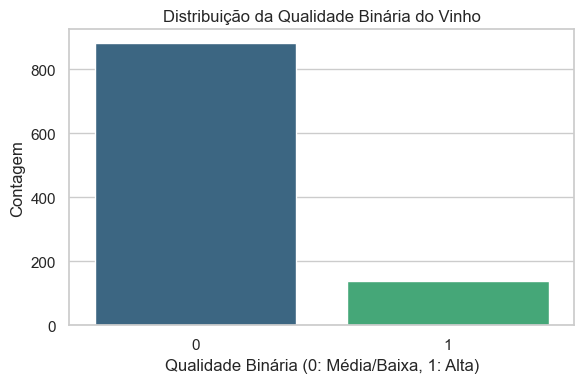

In [83]:
# Gráfico de distribuição da variável alvo

plt.figure(figsize=(6, 4))

sns.countplot(
    x="quality_binary",
    data=wine_df,
    hue="quality_binary",
    palette="viridis",
    legend=False
)

plt.title("Distribuição da Qualidade Binária do Vinho")
plt.xlabel('Qualidade Binária (0: Média/Baixa, 1: Alta)')
plt.ylabel("Contagem")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "distribuicao_quality_binary.png", bbox_inches="tight")
plt.show()

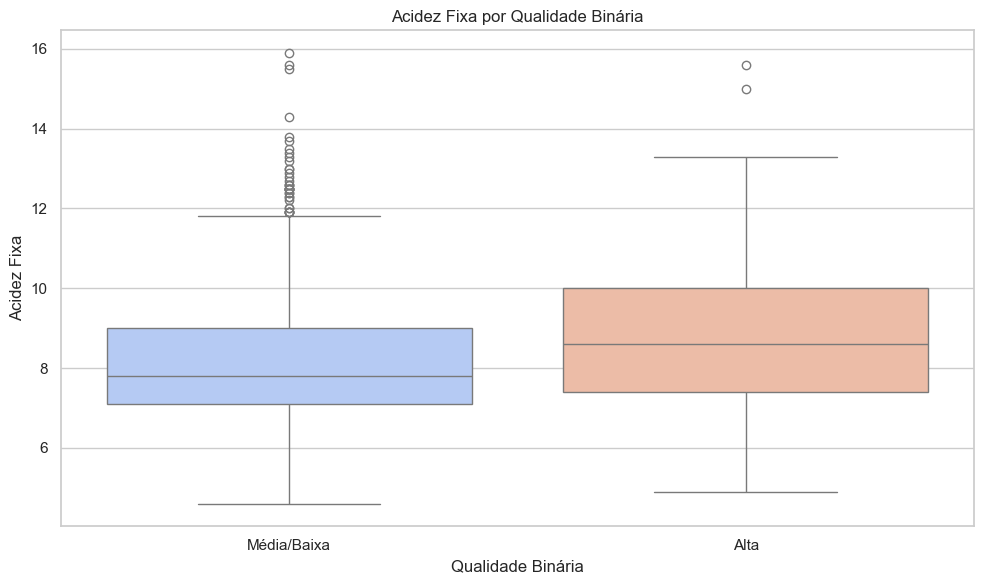

In [84]:
# Boxplots das variáveis químicas em relação à qualidade binária
# Objetivo: comparar a distribuição de cada variável entre vinhos de média/baixa qualidade e alta qualidade.

# Boxplot - Fixed Acidity por Quality Binary

plt.figure(figsize=(10, 6))

sns.boxplot(
    x="quality_binary",
    y="fixed acidity",
    data=wine_df,
    hue="quality_binary",
    palette="coolwarm",
    legend=False
)

plt.title("Acidez Fixa por Qualidade Binária")
plt.xlabel("Qualidade Binária")
plt.ylabel("Acidez Fixa")
plt.xticks([0, 1], ["Média/Baixa", "Alta"])

plt.tight_layout()
plt.savefig(FIGURES_DIR / "boxplot_fixed_acidity_por_quality_binary.png", bbox_inches="tight")
plt.show()

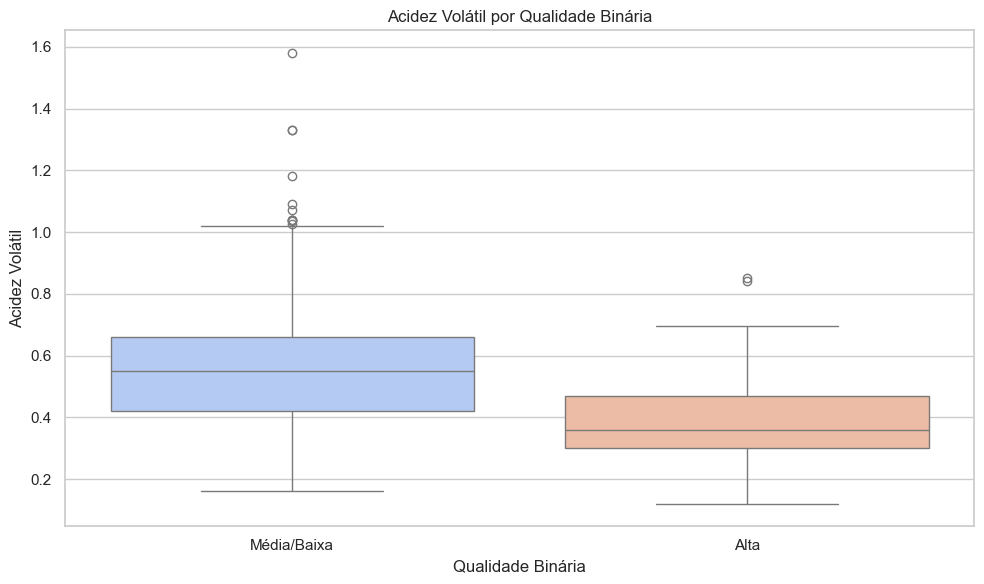

In [85]:
# Boxplot - Volatile Acidity por Quality Binary

plt.figure(figsize=(10, 6))

sns.boxplot(
    x="quality_binary",
    y="volatile acidity",
    data=wine_df,
    hue="quality_binary",
    palette="coolwarm",
    legend=False
)

plt.title("Acidez Volátil por Qualidade Binária")
plt.xlabel("Qualidade Binária")
plt.ylabel("Acidez Volátil")
plt.xticks([0, 1], ["Média/Baixa", "Alta"])

plt.tight_layout()
plt.savefig(FIGURES_DIR / "boxplot_volatile_acidity_por_quality_binary.png", bbox_inches="tight")
plt.show()  

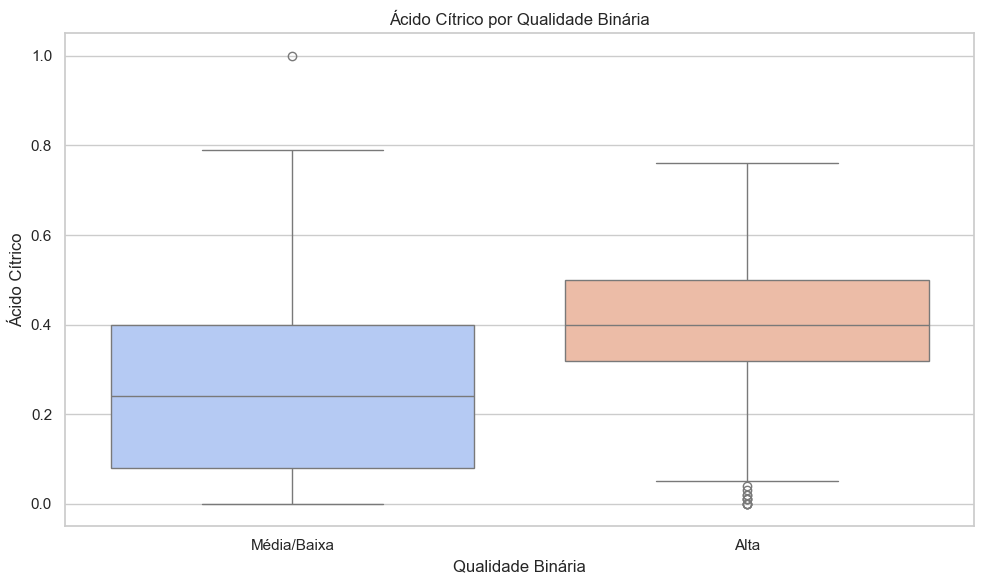

In [86]:
# Boxplot - Citric Acid por Quality Binary

plt.figure(figsize=(10, 6))

sns.boxplot(
    x="quality_binary",
    y="citric acid",
    data=wine_df,
    hue="quality_binary",
    palette="coolwarm",
    legend=False
)

plt.title("Ácido Cítrico por Qualidade Binária")
plt.xlabel("Qualidade Binária")
plt.ylabel("Ácido Cítrico")
plt.xticks([0, 1], ["Média/Baixa", "Alta"])

plt.tight_layout()
plt.savefig(FIGURES_DIR / "boxplot_citric_acid_por_quality_binary.png", bbox_inches="tight")
plt.show()

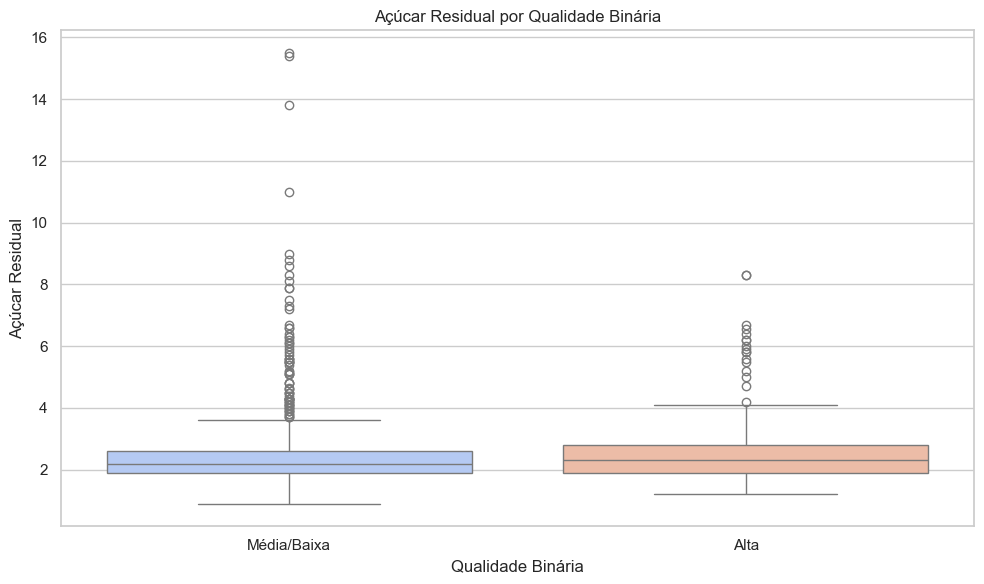

In [87]:
# Boxplot - Residual Sugar por Quality Binary

plt.figure(figsize=(10, 6))

sns.boxplot(
    x="quality_binary",
    y="residual sugar",
    data=wine_df,
    hue="quality_binary",
    palette="coolwarm",
    legend=False
)

plt.title("Açúcar Residual por Qualidade Binária")
plt.xlabel("Qualidade Binária")
plt.ylabel("Açúcar Residual")
plt.xticks([0, 1], ["Média/Baixa", "Alta"])

plt.tight_layout()
plt.savefig(FIGURES_DIR / "boxplot_residual_sugar_por_quality_binary.png", bbox_inches="tight")
plt.show()

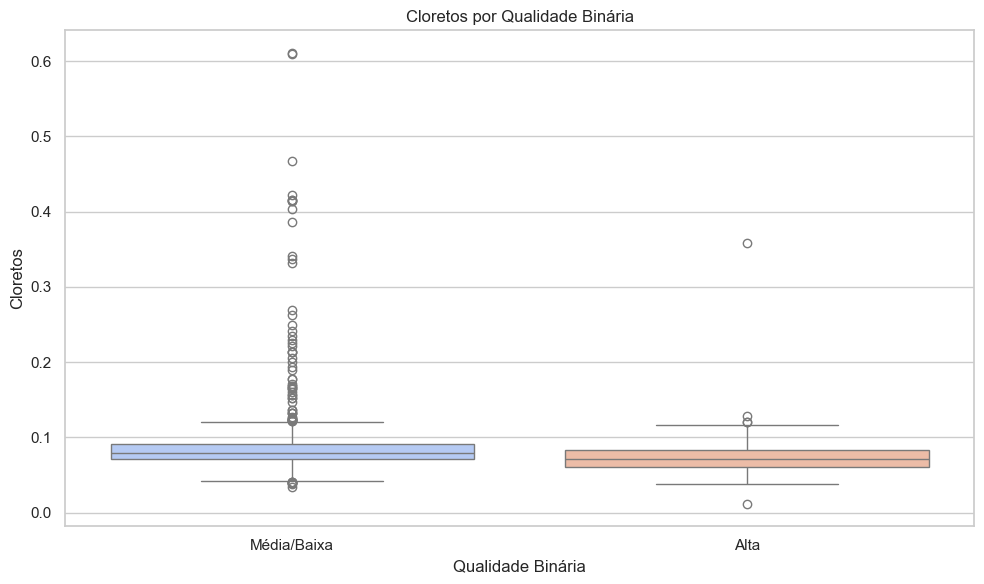

In [88]:
# Boxplot - Chlorides por Quality Binary

plt.figure(figsize=(10, 6))

sns.boxplot(
    x="quality_binary",
    y="chlorides",
    data=wine_df,
    hue="quality_binary",
    palette="coolwarm",
    legend=False
)

plt.title("Cloretos por Qualidade Binária")
plt.xlabel("Qualidade Binária")
plt.ylabel("Cloretos")
plt.xticks([0, 1], ["Média/Baixa", "Alta"])

plt.tight_layout()
plt.savefig(FIGURES_DIR / "boxplot_chlorides_por_quality_binary.png", bbox_inches="tight")
plt.show()

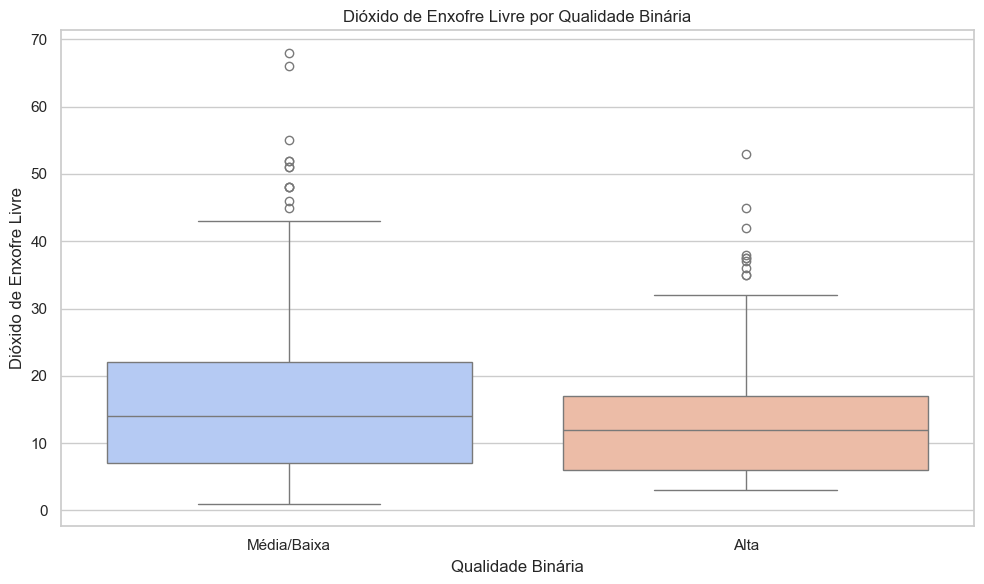

In [89]:
# Boxplot - Free Sulfur Dioxide por Quality Binary

plt.figure(figsize=(10, 6))

sns.boxplot(
    x="quality_binary",
    y="free sulfur dioxide",
    data=wine_df,
    hue="quality_binary",
    palette="coolwarm",
    legend=False
)

plt.title("Dióxido de Enxofre Livre por Qualidade Binária")
plt.xlabel("Qualidade Binária")
plt.ylabel("Dióxido de Enxofre Livre")
plt.xticks([0, 1], ["Média/Baixa", "Alta"])

plt.tight_layout()
plt.savefig(FIGURES_DIR / "boxplot_free_sulfur_dioxide_por_quality_binary.png", bbox_inches="tight")
plt.show()

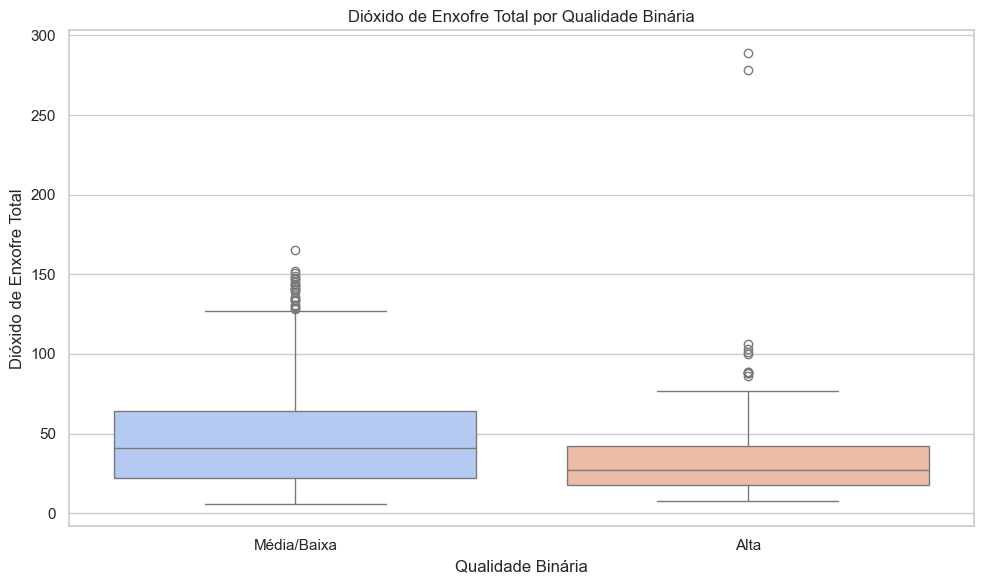

In [90]:
# Boxplot - Total Sulfur Dioxide por Quality Binary

plt.figure(figsize=(10, 6))

sns.boxplot(
    x="quality_binary",
    y="total sulfur dioxide",
    data=wine_df,
    hue="quality_binary",
    palette="coolwarm",
    legend=False
)

plt.title("Dióxido de Enxofre Total por Qualidade Binária")
plt.xlabel("Qualidade Binária")
plt.ylabel("Dióxido de Enxofre Total")
plt.xticks([0, 1], ["Média/Baixa", "Alta"])

plt.tight_layout()
plt.savefig(FIGURES_DIR / "boxplot_total_sulfur_dioxide_por_quality_binary.png", bbox_inches="tight")
plt.show()

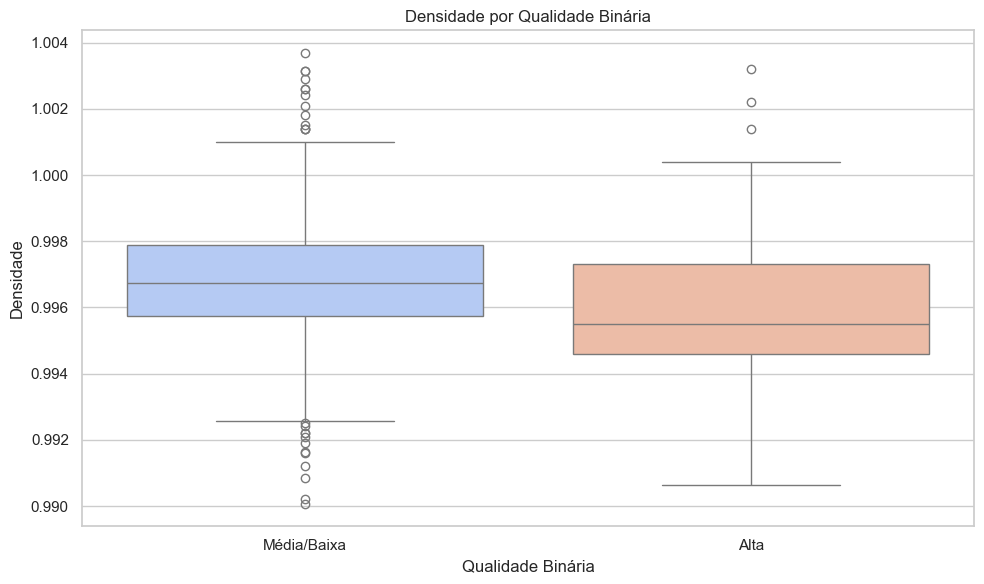

In [91]:
# Boxplot - Density por Quality Binary

plt.figure(figsize=(10, 6))

sns.boxplot(
    x="quality_binary",
    y="density",
    data=wine_df,
    hue="quality_binary",
    palette="coolwarm",
    legend=False
)

plt.title("Densidade por Qualidade Binária")
plt.xlabel("Qualidade Binária")
plt.ylabel("Densidade")
plt.xticks([0, 1], ["Média/Baixa", "Alta"])

plt.tight_layout()
plt.savefig(FIGURES_DIR / "boxplot_density_por_quality_binary.png", bbox_inches="tight")
plt.show()

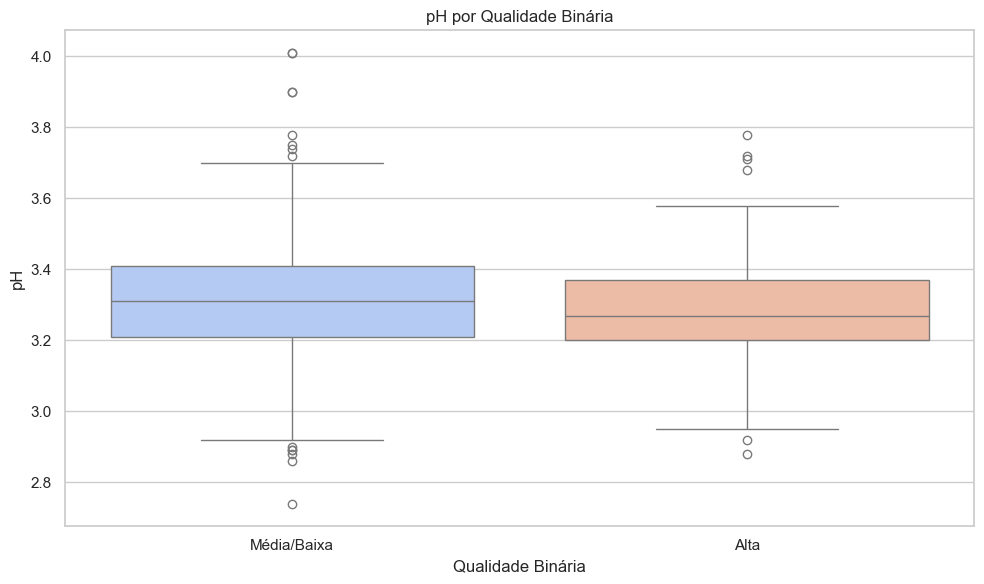

In [92]:
# Boxplot - pH por Quality Binary

plt.figure(figsize=(10, 6))

sns.boxplot(
    x="quality_binary",
    y="pH",
    data=wine_df,
    hue="quality_binary",
    palette="coolwarm",
    legend=False
)

plt.title("pH por Qualidade Binária")
plt.xlabel("Qualidade Binária")
plt.ylabel("pH")
plt.xticks([0, 1], ["Média/Baixa", "Alta"])

plt.tight_layout()
plt.savefig(FIGURES_DIR / "boxplot_ph_por_quality_binary.png", bbox_inches="tight")
plt.show()

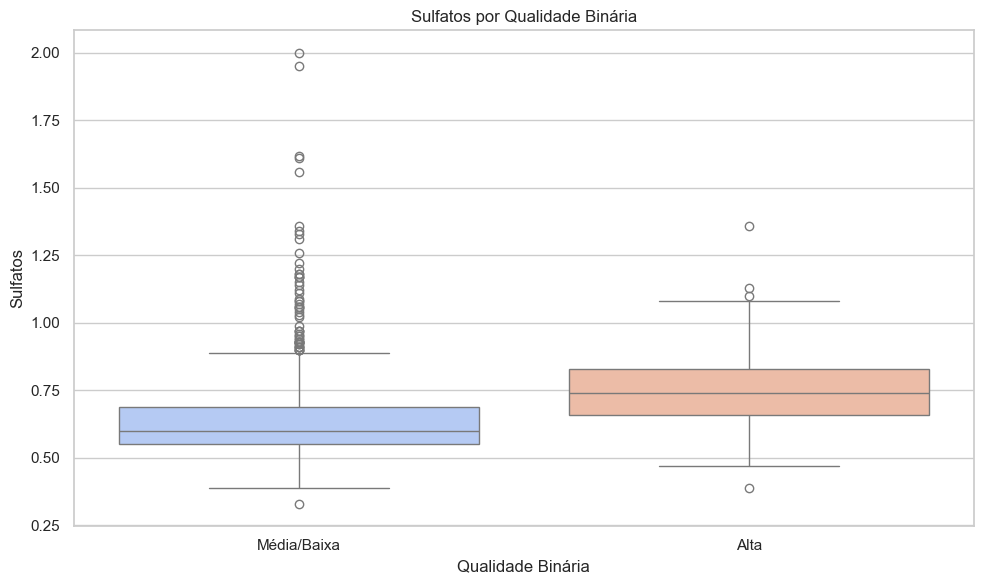

In [93]:
# Boxplot - Sulphates por Quality Binary

plt.figure(figsize=(10, 6))

sns.boxplot(
    x="quality_binary",
    y="sulphates",
    data=wine_df,
    hue="quality_binary",
    palette="coolwarm",
    legend=False
)

plt.title("Sulfatos por Qualidade Binária")
plt.xlabel("Qualidade Binária")
plt.ylabel("Sulfatos")
plt.xticks([0, 1], ["Média/Baixa", "Alta"])

plt.tight_layout()
plt.savefig(FIGURES_DIR / "boxplot_sulphates_por_quality_binary.png", bbox_inches="tight")
plt.show()

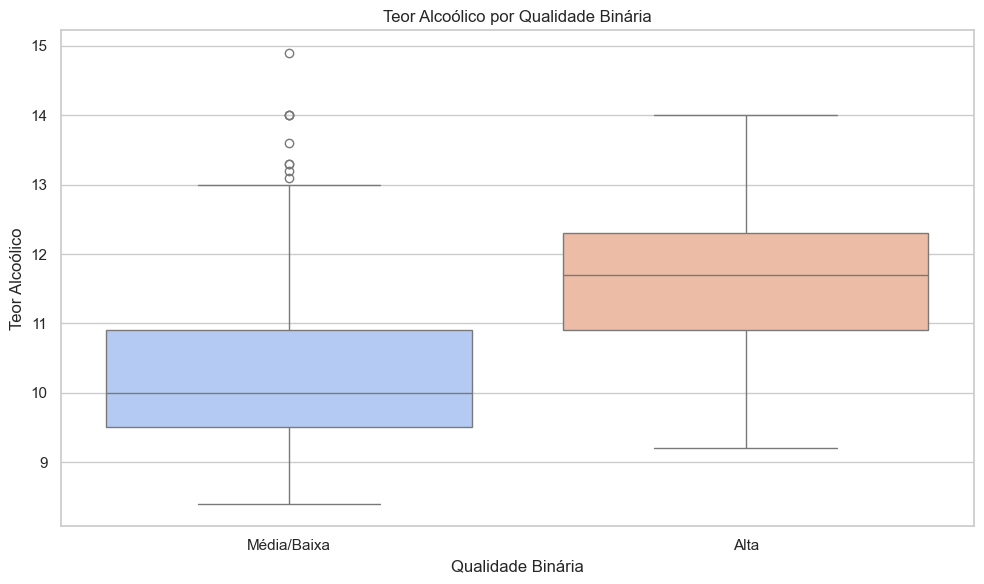

In [94]:
# Boxplot - Alcohol por Quality Binary

plt.figure(figsize=(10, 6))

sns.boxplot(
    x="quality_binary",
    y="alcohol",
    data=wine_df,
    hue="quality_binary",
    palette="coolwarm",
    legend=False
)

plt.title("Teor Alcoólico por Qualidade Binária")
plt.xlabel("Qualidade Binária")
plt.ylabel("Teor Alcoólico")
plt.xticks([0, 1], ["Média/Baixa", "Alta"])

plt.tight_layout()
plt.savefig(FIGURES_DIR / "boxplot_alcohol_por_quality_binary.png", bbox_inches="tight")
plt.show()